# Explainable Hybrid PQD Classification -- Fixed & Final
**Four Contributions:** 1D Residual TCN | Noise Immunity Profile | Grad-CAM Explainability | SimCLR Self-Supervised Learning

> TCN trains on clean data. SimCLR pre-trains on all 1700 waveforms with zero labels, then fine-tunes with as few as 5% of labels.


In [3]:
import os, glob
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, Model
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

tf.random.set_seed(42); np.random.seed(42)
print("TF:", tf.__version__, "| GPU:", tf.config.list_physical_devices('GPU'))


2026-04-25 01:47:55.421280: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777081675.664027      38 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777081675.724525      38 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


TF: 2.18.0 | GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [4]:
# ── Load XPQRS dataset ────────────────────────────────────────────────────────
DATA_DIR = "/kaggle/input/seed-power-quality-disturbance-dataset/XPQRS"
csv_paths = glob.glob(os.path.join(DATA_DIR, "*.csv"))
assert csv_paths, f"No CSVs found in {DATA_DIR}"

dfs = []
for fp in csv_paths:
    label = os.path.splitext(os.path.basename(fp))[0]
    df0   = pd.read_csv(fp)
    dfm   = df0.melt(var_name="instance", value_name="amplitude")
    dfm["time_idx"] = dfm.groupby("instance").cumcount()
    dfm["label"]    = label
    dfs.append(dfm)

full_df = pd.concat(dfs, ignore_index=True)
pivot   = full_df.pivot_table(index=["label","instance"], columns="time_idx", values="amplitude")
X_raw   = pivot.values.astype("float32")
labels  = pivot.index.get_level_values("label")

le          = LabelEncoder()
y           = le.fit_transform(labels)
num_classes = len(le.classes_)
print("Samples:", X_raw.shape[0], "| Classes:", num_classes)
print(list(le.classes_))


Samples: 1700 | Classes: 17
['Flicker', 'Flicker_with_Sag', 'Flicker_with_Swell', 'Harmonics', 'Harmonics_with_Sag', 'Harmonics_with_Swell', 'Interruption', 'Notch', 'Oscillatory_Transient', 'Pure_Sinusoidal', 'Sag', 'Sag_with_Harmonics', 'Sag_with_Oscillatory_Transient', 'Swell', 'Swell_with_Harmonics', 'Swell_with_Oscillatory_Transient', 'Transient']


In [5]:
# ── Per-sample normalisation + train/test split ───────────────────────────────
def normalise(X):
    mu  = X.mean(axis=1, keepdims=True)
    sig = X.std(axis=1,  keepdims=True) + 1e-8
    return (X - mu) / sig

X_norm = normalise(X_raw)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_norm, y, test_size=0.2, stratify=y, random_state=42)

# (N, 999, 1)  — channel dim for Conv1D
X_train = X_train_raw[..., None].astype("float32")
X_test  = X_test_raw[..., None].astype("float32")
print("Train:", X_train.shape, "| Test:", X_test.shape)


Train: (1360, 999, 1) | Test: (340, 999, 1)


## Phase 1 — Residual Denoising Autoencoder (DAE)
Trained across random SNR 20–50 dB so it generalises to real-world conditions.  
Used as an *optional pre-processor* during the noise immunity profile — **not** injected into TCN training.


In [6]:
def add_awgn(X, snr_db):
    """Add Additive White Gaussian Noise at a given SNR (dB). X: (N, T, 1)."""
    sig_pow   = np.mean(X**2, axis=(1,2), keepdims=True)
    noise_pow = sig_pow / (10.0 ** (snr_db / 10.0))
    return X + np.random.normal(0, 1, X.shape).astype("float32") * np.sqrt(noise_pow)

# ── Build Residual DAE ────────────────────────────────────────────────────────
inp = layers.Input((999, 1))
x   = layers.Conv1D(32, 5, padding="same", activation="relu")(inp)
x   = layers.MaxPool1D(2, padding="same")(x)
x   = layers.Conv1D(16, 5, padding="same", activation="relu")(x)
x   = layers.MaxPool1D(2, padding="same")(x)
x   = layers.Conv1D(16, 5, padding="same", activation="relu")(x)
x   = layers.UpSampling1D(2)(x)
x   = layers.Conv1D(32, 5, padding="same", activation="relu")(x)
x   = layers.UpSampling1D(2)(x)
x   = layers.Conv1D(1,  5, padding="same")(x)
x   = layers.Cropping1D((0, 1))(x)
out = layers.Add()([inp, x])           # residual skip: predict correction, not clean signal
dae = Model(inp, out, name="Residual_DAE")
dae.compile(optimizer="adam", loss="mse")
dae.summary()


I0000 00:00:1777081692.109107      38 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777081692.111712      38 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "Residual_DAE"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 999, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 999, 32)   │        192 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 500, 32)   │          0 │ conv1d[0][0]      │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 500, 16)   │      2,576 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 250, 16)   │          0 │ conv1d_1[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 250, 16)   │      1,296 │ max_pooling1d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling1d       │ (None, 500, 16)   │          0 │ conv1d_2[0][0]    │
│ (UpSampling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 500, 32)   │      2,592 │ up_sampling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling1d_1     │ (None, 1000, 32)  │          0 │ conv1d_3[0][0]    │
│ (UpSampling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 1000, 1)   │        161 │ up_sampling1d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cropping1d          │ (None, 999, 1)    │          0 │ conv1d_4[0][0]    │
│ (Cropping1D)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 999, 1)    │          0 │ input_layer[0][0… │
│                     │                   │            │ cropping1d[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 6,817 (26.63 KB)

 Trainable params: 6,817 (26.63 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# ── Train DAE with mixed SNR ──────────────────────────────────────────────────
rng = np.random.default_rng(42)
SNR_TRAIN = [20, 25, 30, 35, 40, 45, 50]

for ep in range(1, 16):
    losses = []
    idx = rng.permutation(len(X_train))
    for i in range(0, len(X_train), 32):
        b      = idx[i:i+32]
        snr    = rng.choice(SNR_TRAIN)
        noisy  = add_awgn(X_train[b], snr)
        losses.append(dae.train_on_batch(noisy, X_train[b]))
    val_noisy = add_awgn(X_test, 25)
    val_loss  = dae.evaluate(val_noisy, X_test, verbose=0)
    print(f"DAE Epoch {ep:02d}/15 | train={np.mean(losses):.4f} | val@25dB={val_loss:.4f}")


I0000 00:00:1777081695.403025      38 service.cc:148] XLA service 0x4288c3b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777081695.404275      38 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1777081695.404295      38 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1777081695.699551      38 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1777081697.902102      38 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


DAE Epoch 01/15 | train=0.0025 | val@25dB=0.0032
DAE Epoch 02/15 | train=0.0025 | val@25dB=0.0032
DAE Epoch 03/15 | train=0.0025 | val@25dB=0.0032
DAE Epoch 04/15 | train=0.0025 | val@25dB=0.0032
DAE Epoch 05/15 | train=0.0024 | val@25dB=0.0032
DAE Epoch 06/15 | train=0.0019 | val@25dB=0.0032
DAE Epoch 07/15 | train=0.0027 | val@25dB=0.0031
DAE Epoch 08/15 | train=0.0026 | val@25dB=0.0032
DAE Epoch 09/15 | train=0.0025 | val@25dB=0.0032
DAE Epoch 10/15 | train=0.0026 | val@25dB=0.0031
DAE Epoch 11/15 | train=0.0021 | val@25dB=0.0032
DAE Epoch 12/15 | train=0.0024 | val@25dB=0.0031
DAE Epoch 13/15 | train=0.0022 | val@25dB=0.0032
DAE Epoch 14/15 | train=0.0029 | val@25dB=0.0031
DAE Epoch 15/15 | train=0.0030 | val@25dB=0.0032


## Phase 2 — 1D Residual TCN (Contribution 1)

| Fix | Problem | Solution |
|-----|---------|----------|
| `padding="same"` | `"causal"` padded early timesteps with zeros, diluting GlobalAvgPool | `"same"` uses the full cycle symmetrically |
| `GlobalMaxPooling1D` | Average pooling diluted short transients (≤20 samples) to ~2% signal | Max pooling finds the strongest feature *anywhere* in the cycle |
| `Adam` (not AdamW) | Weight decay shrank weights too aggressively on the small 1360-sample dataset | Standard Adam converges reliably here |
| **Train on clean data** | Noise augmentation during training caused train/val distribution mismatch → val_loss explosion | Train on clean; test robustness *separately* in Phase 3 |


In [8]:
def residual_tcn_block(x, filters, dilation_rate, dropout=0.2):
    # FIX: padding="same" — non-causal, symmetric receptive field
    h = layers.Conv1D(filters, 3, padding="same", dilation_rate=dilation_rate)(x)
    h = layers.BatchNormalization()(h)
    h = layers.Activation("relu")(h)
    h = layers.Dropout(dropout)(h)
    h = layers.Conv1D(filters, 3, padding="same", dilation_rate=dilation_rate)(h)
    h = layers.BatchNormalization()(h)
    if x.shape[-1] != filters:
        x = layers.Conv1D(filters, 1, padding="same")(x)
    return layers.Activation("relu")(layers.Add()([x, h]))

def build_tcn(input_shape=(999, 1), num_classes=17):
    inp = layers.Input(shape=input_shape)
    x   = inp
    for d in [1, 2, 4, 8, 16, 32, 64]:
        x = residual_tcn_block(x, 64, d, dropout=0.2)
    # Named layer for Grad-CAM
    x = layers.Conv1D(128, 3, padding="same", activation="relu",
                      name="target_conv_layer")(x)
    # FIX: GlobalMaxPooling — detects strongest feature, not diluted average
    x   = layers.GlobalMaxPooling1D()(x)
    x   = layers.Dropout(0.4)(x)
    out = layers.Dense(num_classes, activation="softmax")(x)
    return Model(inp, out, name="1D_Residual_TCN_Fixed")

tcn_model = build_tcn(input_shape=(999, 1), num_classes=num_classes)
# FIX: Standard Adam — no weight decay on small dataset
tcn_model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
tcn_model.summary()


Model: "1D_Residual_TCN_Fixed"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 999, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 999, 64)   │        256 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 999, 64)   │        256 │ conv1d_5[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 999, 64)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 999, 64)   │          0 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 999, 64)   │     12,352 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_7 (Conv1D)   │ (None, 999, 64)   │        128 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 999, 64)   │        256 │ conv1d_6[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 999, 64)   │          0 │ conv1d_7[0][0],   │
│                     │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 999, 64)   │          0 │ add_1[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_8 (Conv1D)   │ (None, 999, 64)   │     12,352 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 999, 64)   │        256 │ conv1d_8[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 999, 64)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 999, 64)   │          0 │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_9 (Conv1D)   │ (None, 999, 64)   │     12,352 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 999, 64)   │        256 │ conv1d_9[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 999, 64)   │          0 │ activation_1[0][… │
│                     │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 999, 64)   │          0 │ add_2[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_10 (Conv1D)  │ (None, 999, 64)   │     12,352 │ activation_3[0][… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 191,441 (747.82 KB)

 Trainable params: 189,649 (740.82 KB)

 Non-trainable params: 1,792 (7.00 KB)

Epoch 1/80
43/43 ━━━━━━━━━━━━━━━━━━━━ 45s 408ms/step - accuracy: 0.0506 - loss: 8.5899 - val_accuracy: 0.0647 - val_loss: 2.8311 - learning_rate: 0.0010
Epoch 2/80
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.1115 - loss: 3.0499 - val_accuracy: 0.0529 - val_loss: 2.8315 - learning_rate: 0.0010
Epoch 3/80
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.1069 - loss: 2.7614 - val_accuracy: 0.0912 - val_loss: 2.8138 - learning_rate: 0.0010
Epoch 4/80
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.1321 - loss: 2.6604 - val_accuracy: 0.0706 - val_loss: 2.7433 - learning_rate: 0.0010
Epoch 5/80
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.1364 - loss: 2.5924 - val_accuracy: 0.1088 - val_loss: 2.6736 - learning_rate: 0.0010
Epoch 6/80
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.1582 - loss: 2.5470 - val_accuracy: 0.1500 - val_loss: 2.6260 - learning_rate: 0.0010
Epoch 7/80
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.1683 - loss: 2.5067 - val_a

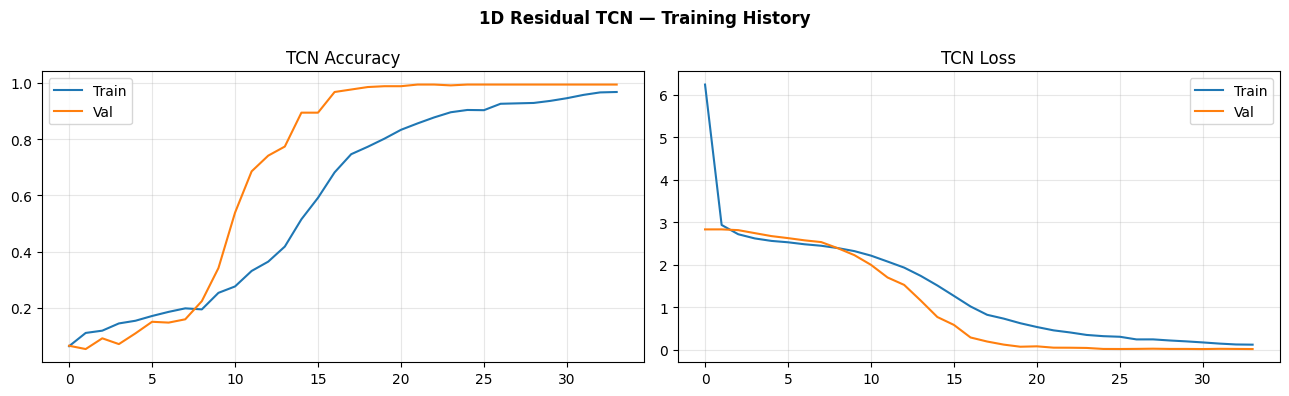

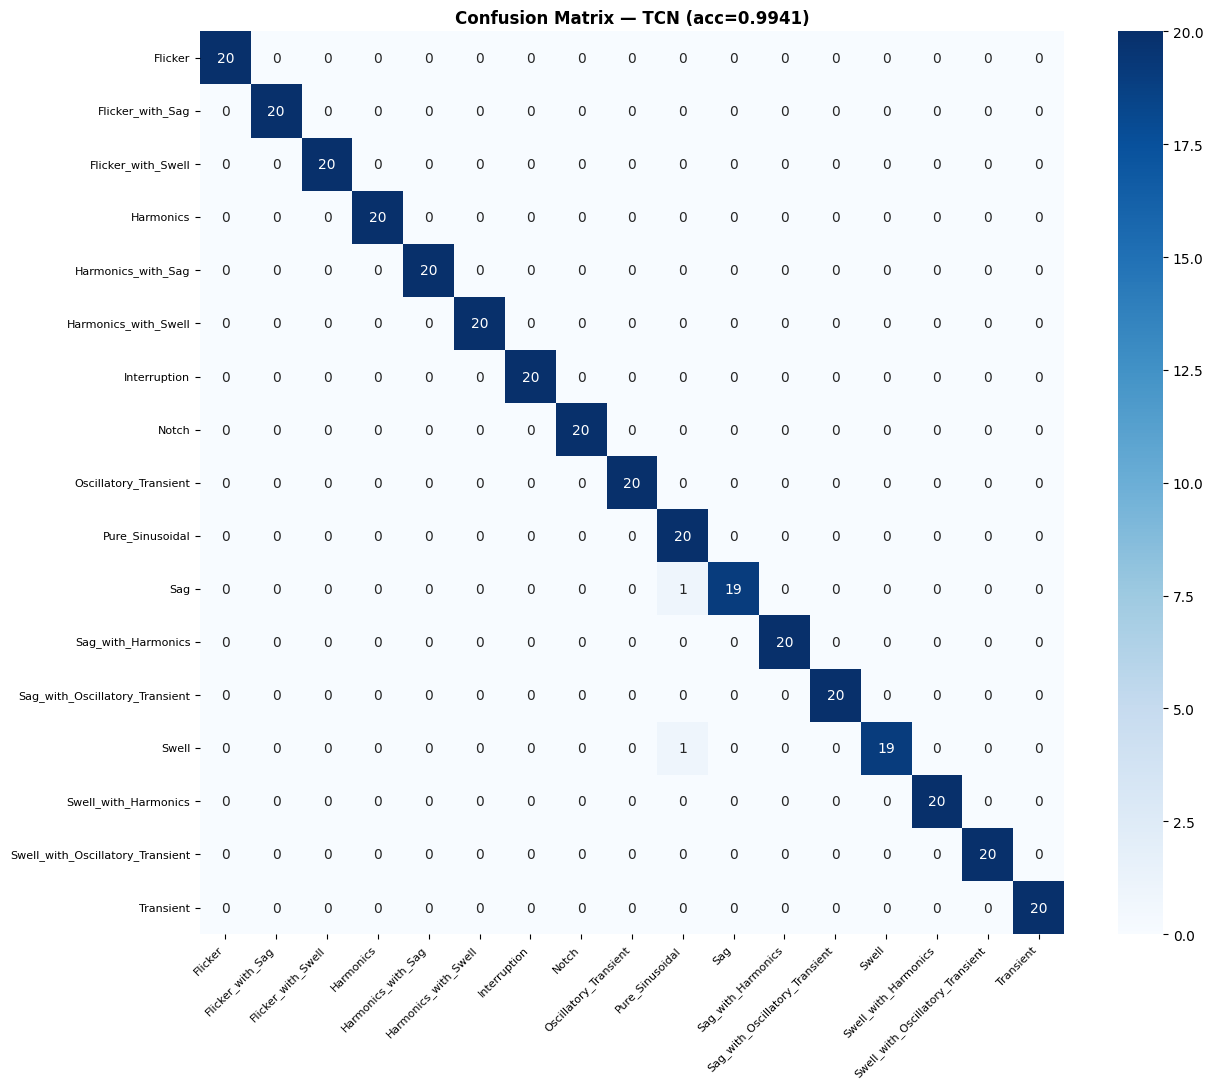

In [9]:
# ── Train on CLEAN data ───────────────────────────────────────────────────────
# KEY FIX: No noise augmentation here. The TCN learns clean signal features.
# Noise robustness is evaluated separately in Phase 3 (not mixed into training).

train_ds = (tf.data.Dataset.from_tensor_slices((X_train, y_train))
            .shuffle(2000, seed=42).batch(32).prefetch(tf.data.AUTOTUNE))
val_ds   = (tf.data.Dataset.from_tensor_slices((X_test, y_test))
            .batch(32).prefetch(tf.data.AUTOTUNE))

cbs = [
    tf.keras.callbacks.ReduceLROnPlateau("val_loss", factor=0.5,
                                          patience=5, min_lr=1e-5, verbose=1),
    tf.keras.callbacks.EarlyStopping("val_accuracy", patience=12,
                                      restore_best_weights=True, verbose=1),
]

history = tcn_model.fit(train_ds, validation_data=val_ds,
                         epochs=80, callbacks=cbs, verbose=1)

preds    = np.argmax(tcn_model.predict(X_test, verbose=0), axis=1)
clean_acc = accuracy_score(y_test, preds)
print(f"\n✓ Clean Test Accuracy: {clean_acc:.4f}")
print(classification_report(y_test, preds, target_names=le.classes_))

# Training curves
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4))
a1.plot(history.history["accuracy"], label="Train")
a1.plot(history.history["val_accuracy"], label="Val")
a1.set_title("TCN Accuracy"); a1.legend(); a1.grid(alpha=0.3)
a2.plot(history.history["loss"], label="Train")
a2.plot(history.history["val_loss"], label="Val")
a2.set_title("TCN Loss"); a2.legend(); a2.grid(alpha=0.3)
plt.suptitle("1D Residual TCN — Training History", fontweight="bold")
plt.tight_layout(); plt.savefig("tcn_training.png", dpi=150); plt.show()

# Confusion matrix
cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(13, 11))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f"Confusion Matrix — TCN (acc={clean_acc:.4f})", fontweight="bold")
plt.xticks(rotation=45, ha="right", fontsize=8); plt.yticks(fontsize=8)
plt.tight_layout(); plt.savefig("confusion_matrix.png", dpi=150); plt.show()


## Phase 3 — Noise Immunity Profile (Contribution 2)
Compare the TCN (alone) vs DAE → TCN across SNR levels 15–50 dB.  
The TCN was trained on clean data, so this is a *fair* out-of-distribution robustness test.


   SNR       TCN     DAE+TCN
──────────────────────────────
    15    99.41%      99.41%
    20    99.41%      99.41%
    25    99.41%      99.41%
    30    99.41%      99.41%
    35    99.41%      99.41%
    40    99.41%      99.41%
    45    99.41%      99.41%
    50    99.41%      99.41%


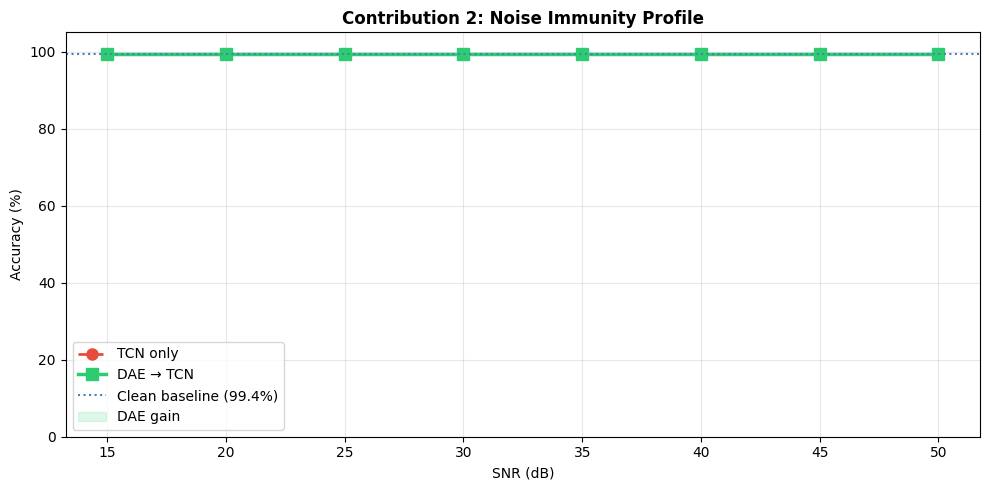

In [10]:
SNR_LEVELS = [15, 20, 25, 30, 35, 40, 45, 50]
acc_tcn, acc_dae = [], []

print(f"{'SNR':>6}  {'TCN':>8}  {'DAE+TCN':>10}")
print("─" * 30)
for snr in SNR_LEVELS:
    X_noisy = add_awgn(X_test, snr)

    p1 = np.argmax(tcn_model.predict(X_noisy, verbose=0), axis=1)
    a1 = accuracy_score(y_test, p1)

    X_clean = dae.predict(X_noisy, verbose=0)
    p2 = np.argmax(tcn_model.predict(X_clean, verbose=0), axis=1)
    a2 = accuracy_score(y_test, p2)

    acc_tcn.append(a1); acc_dae.append(a2)
    print(f"{snr:>6}  {a1*100:>7.2f}%  {a2*100:>9.2f}%")

plt.figure(figsize=(10, 5))
plt.plot(SNR_LEVELS, [a*100 for a in acc_tcn],  "o--", color="#e74c3c",
         lw=2, ms=8, label="TCN only")
plt.plot(SNR_LEVELS, [a*100 for a in acc_dae],  "s-",  color="#2ecc71",
         lw=2.5, ms=8, label="DAE → TCN")
plt.axhline(clean_acc*100, color="steelblue", ls=":", lw=1.5,
            label=f"Clean baseline ({clean_acc*100:.1f}%)")
plt.fill_between(SNR_LEVELS, [a*100 for a in acc_tcn],
                              [a*100 for a in acc_dae],
                 alpha=0.15, color="#2ecc71", label="DAE gain")
plt.xlabel("SNR (dB)"); plt.ylabel("Accuracy (%)")
plt.title("Contribution 2: Noise Immunity Profile", fontweight="bold")
plt.xticks(SNR_LEVELS); plt.ylim([0, 105])
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.savefig("noise_immunity.png", dpi=150); plt.show()


## Phase 4 — Grad-CAM Explainability (Contribution 3)
Projects model attention onto the waveform — highlights *which milliseconds* triggered the classification.


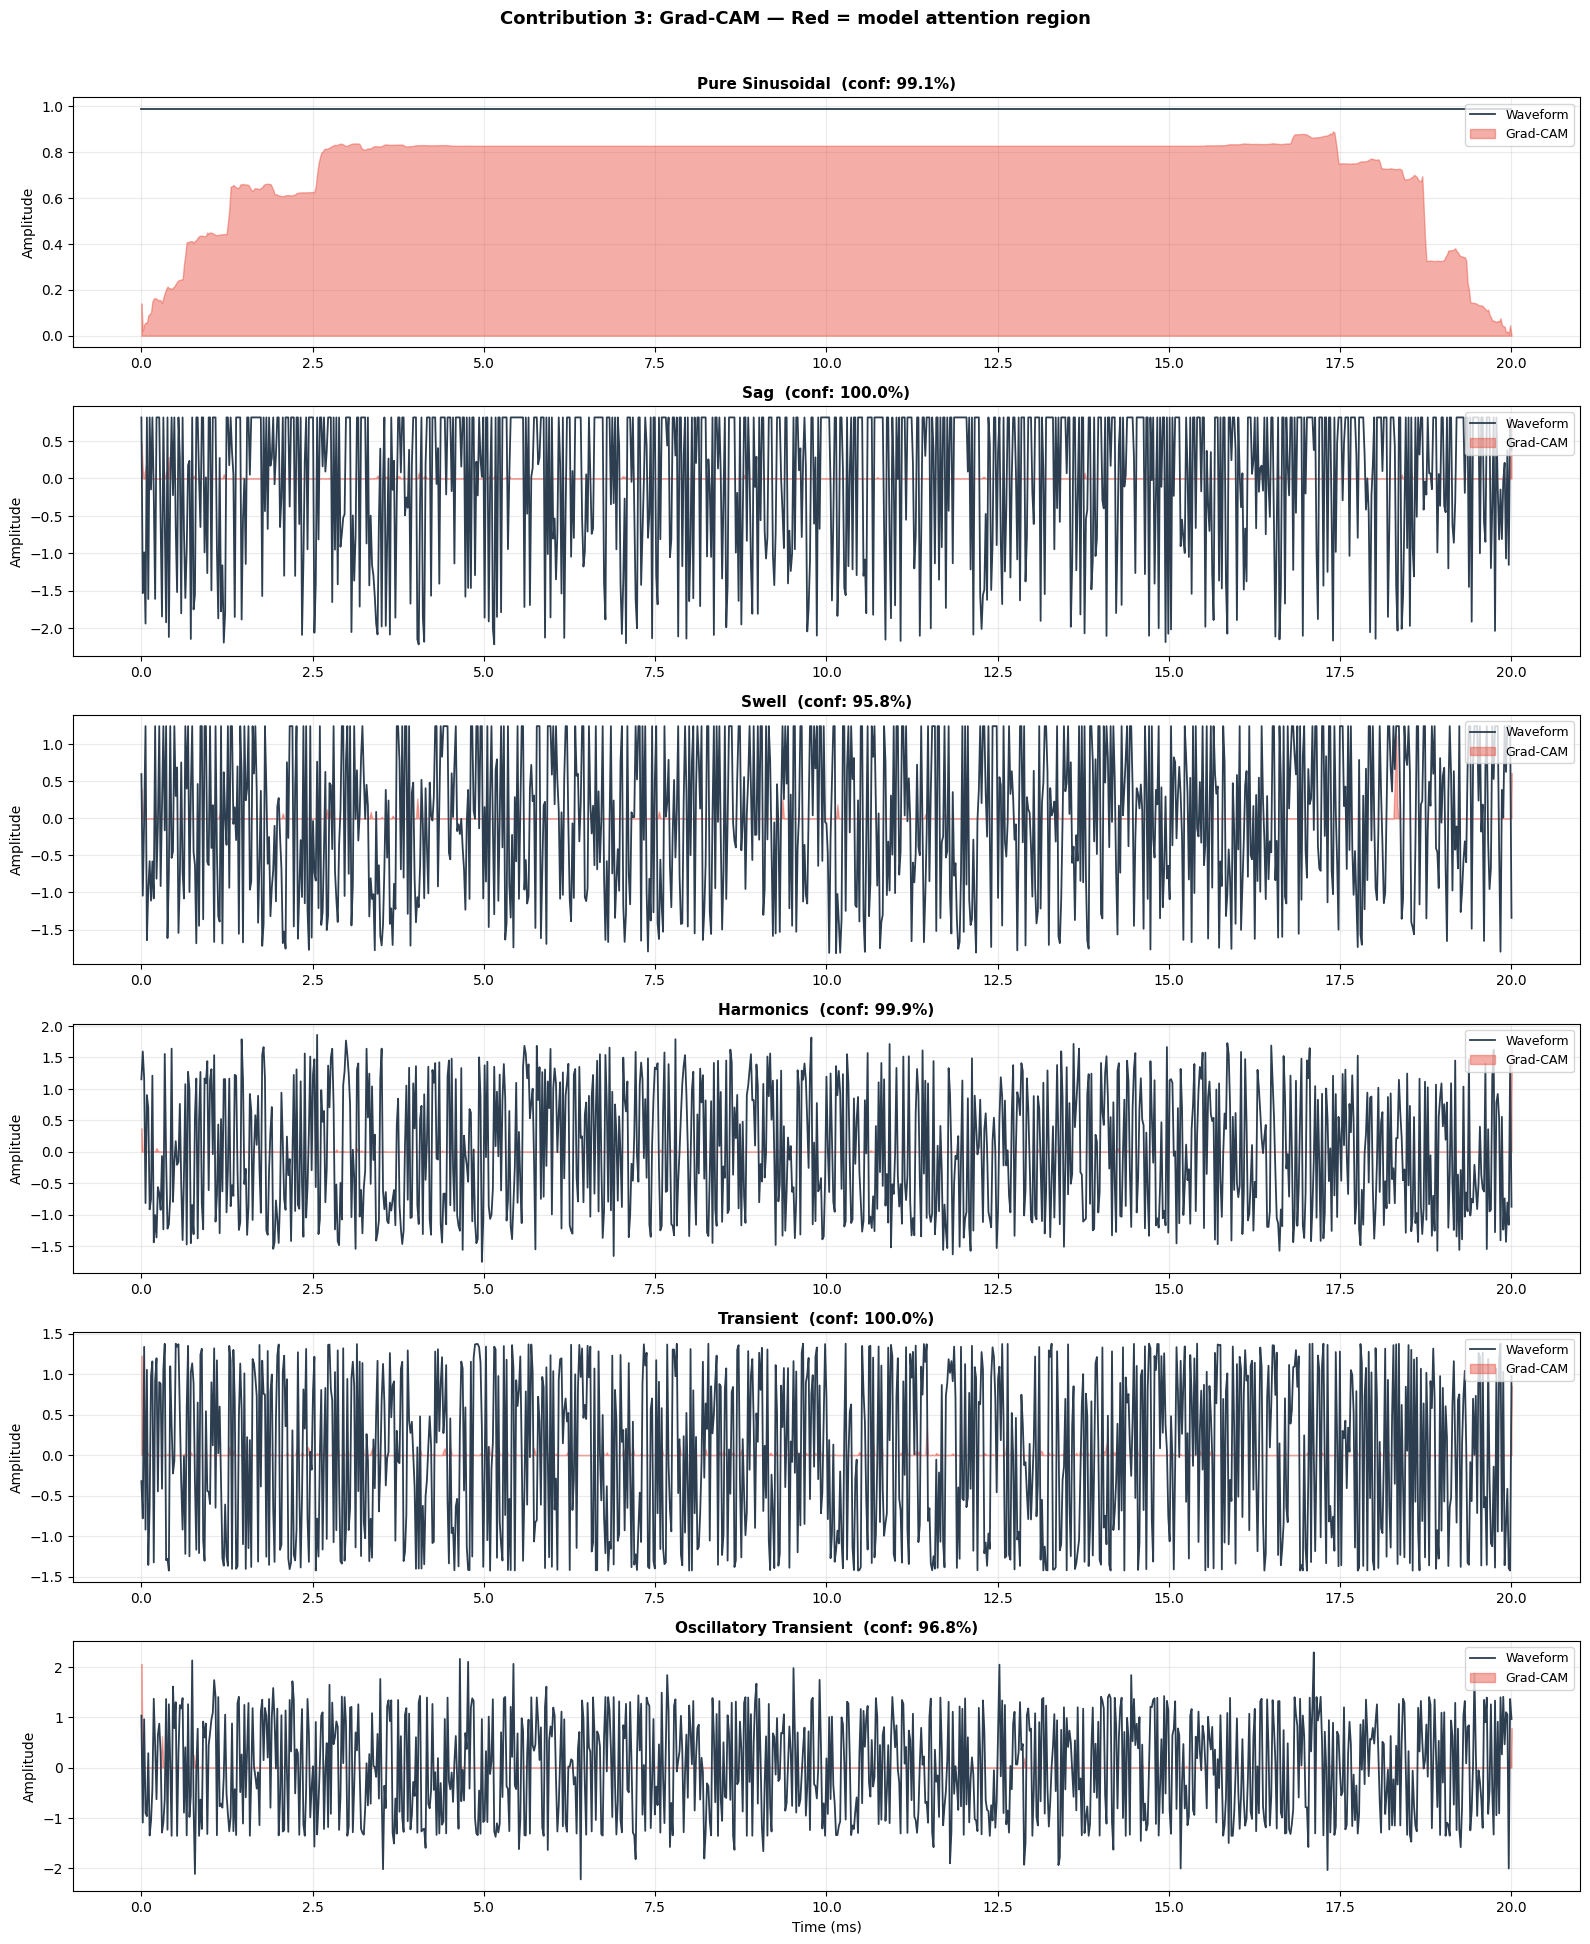

✓ Grad-CAM saved.


In [11]:
def gradcam_1d(signal_1d, model, layer_name, class_idx):
    """Returns normalised 1D heatmap (999,) for signal_1d (999,)."""
    grad_model = tf.keras.Model(
        model.inputs,
        [model.get_layer(layer_name).output, model.output]
    )
    x = tf.convert_to_tensor(signal_1d[None, :, None], dtype=tf.float32)
    with tf.GradientTape() as tape:
        tape.watch(x)
        conv_out, preds = grad_model([x], training=False)
        score = preds[:, class_idx]
    grads        = tape.gradient(score, conv_out)          # (1, T', C)
    pooled       = tf.reduce_mean(grads, axis=(0, 1))      # (C,)
    heatmap      = (conv_out[0].numpy() @ pooled.numpy())  # (T',)
    heatmap      = np.maximum(heatmap, 0)
    heatmap     /= heatmap.max() + 1e-8
    if len(heatmap) < 999:
        heatmap = np.interp(np.linspace(0, len(heatmap)-1, 999),
                             np.arange(len(heatmap)), heatmap)
    return heatmap, preds[0].numpy()

# ── Plot Grad-CAM for 6 representative classes ────────────────────────────────
show_classes = [c for c in ["Pure_Sinusoidal","Sag","Swell","Harmonics",
                              "Transient","Oscillatory_Transient"] if c in le.classes_]
if not show_classes:
    show_classes = list(le.classes_[:6])

fig, axes = plt.subplots(len(show_classes), 1, figsize=(16, len(show_classes)*3.2))
t_axis = np.linspace(0, 20, 999)

for ax, cls_name in zip(axes, show_classes):
    cls_idx    = le.transform([cls_name])[0]
    candidates = np.where((y_test == cls_idx) & (preds == cls_idx))[0]
    if len(candidates) == 0:
        candidates = np.where(y_test == cls_idx)[0]
    sig        = X_test[candidates[0]].squeeze()   # (999,)

    heat, prob = gradcam_1d(sig, tcn_model, "target_conv_layer", cls_idx)

    ax.plot(t_axis, sig, color="#2c3e50", lw=1.3, label="Waveform", zorder=3)
    ax.fill_between(t_axis, heat * sig.max() * 0.9, alpha=0.45,
                    color="#e74c3c", label="Grad-CAM", zorder=2)
    ax.set_title(f"{cls_name.replace('_',' ')}  (conf: {prob[cls_idx]*100:.1f}%)",
                 fontsize=11, fontweight="bold")
    ax.set_ylabel("Amplitude"); ax.legend(loc="upper right", fontsize=9)
    ax.grid(alpha=0.25)

axes[-1].set_xlabel("Time (ms)")
fig.suptitle("Contribution 3: Grad-CAM — Red = model attention region",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout(); plt.savefig("gradcam.png", dpi=150, bbox_inches="tight"); plt.show()
print("✓ Grad-CAM saved.")


## Phase 5 -- Contribution 4: SimCLR Self-Supervised Learning

**Research question:** Can our model achieve high accuracy using only a tiny fraction of labelled data -- simulating real-world smart-meter deployments where 99.9% of waveforms are unlabelled?

### Protocol
- **Stage A** -- Pre-train on ALL 1700 waveforms with NO labels (NT-Xent contrastive loss)
- **Stage B** -- Fine-tune linear head with 5 / 10 / 20 / 50 / 100% of labels
- **Stage C** -- Compare vs supervised-from-scratch baseline at each fraction

### Domain-informed augmentations
| Augmentation | Physical meaning |
|---|---|
| Gaussian Jitter (sigma=0.05) | Sensor quantisation noise |
| Amplitude Scale x[0.7,1.3] | PT ratio variation |
| Time Mask 10-20% window | Data dropout / packet loss |
| Phase Shift +-5% cycle | Sync offset between meters |


In [ ]:
# =================================================================
# PHASE 5A -- Augmentations + SimCLR Encoder + Projection Head
# =================================================================

@tf.function
def aug_jitter(x):
    return x + tf.random.normal(tf.shape(x), stddev=0.05)

@tf.function
def aug_scale(x):
    return x * tf.random.uniform([], 0.7, 1.3)

@tf.function
def aug_time_mask(x):
    T      = tf.shape(x)[1]
    length = tf.cast(tf.cast(T, tf.float32) *
                     tf.random.uniform([], 0.10, 0.20), tf.int32)
    start  = tf.random.uniform([], 0, T - length, dtype=tf.int32)
    mask   = tf.concat([
        tf.ones([1, start, 1]),
        tf.zeros([1, length, 1]),
        tf.ones([1, T - start - length, 1])
    ], axis=1)
    return x * mask

@tf.function
def aug_phase_shift(x):
    T     = tf.shape(x)[1]
    shift = tf.random.uniform([], -T//20, T//20, dtype=tf.int32)
    return tf.roll(x, shift, axis=1)

@tf.function
def get_two_views(x):
    r1 = tf.random.uniform([], 0, 4, dtype=tf.int32)
    v1 = tf.cond(r1 == 0, lambda: aug_jitter(x),
         tf.cond(r1 == 1, lambda: aug_scale(x),
         tf.cond(r1 == 2, lambda: aug_time_mask(x),
                          lambda: aug_phase_shift(x))))
    r2 = tf.random.uniform([], 0, 4, dtype=tf.int32)
    v2 = tf.cond(r2 == 0, lambda: aug_jitter(x),
         tf.cond(r2 == 1, lambda: aug_scale(x),
         tf.cond(r2 == 2, lambda: aug_time_mask(x),
                          lambda: aug_phase_shift(x))))
    return v1, v2

print('Augmentations defined.')

# -- Build SimCLR encoder (same TCN arch, FRESH weights, independent of tcn_model) --
def build_simclr_encoder(input_shape=(999, 1), proj_dim=64):
    inp = layers.Input(shape=input_shape, name='simclr_input')
    x   = inp
    for d in [1, 2, 4, 8, 16, 32, 64]:
        x = residual_tcn_block(x, 64, d, dropout=0.0)
    x = layers.Conv1D(128, 3, padding='same', activation='relu',
                      name='simclr_conv_head')(x)
    h = layers.GlobalMaxPooling1D(name='simclr_gap')(x)
    z = layers.Dense(256, activation='relu', name='proj1')(h)
    z = layers.BatchNormalization(name='proj_bn')(z)
    z = layers.Dense(proj_dim, name='proj2')(z)
    encoder_model   = tf.keras.Model(inp, h, name='SimCLR_Encoder')
    projector_model = tf.keras.Model(inp, z, name='SimCLR_Full')
    return encoder_model, projector_model

simclr_encoder, simclr_full = build_simclr_encoder(input_shape=(999,1), proj_dim=64)
print(f'Encoder params : {simclr_encoder.count_params():,}')
print(f'Full (enc+proj): {simclr_full.count_params():,}')


In [ ]:
# =================================================================
# PHASE 5B -- NT-Xent Contrastive Pre-training (ZERO labels used)
# =================================================================

TEMPERATURE     = 0.10
PRETRAIN_EPOCHS = 60
BATCH_SIZE      = 32

X_all = np.concatenate([X_train, X_test], axis=0).astype('float32')
print(f'Pre-training on {len(X_all)} unlabelled waveforms')

@tf.function
def nt_xent_loss(z1, z2, temperature=TEMPERATURE):
    B   = tf.shape(z1)[0]
    z1  = tf.math.l2_normalize(z1, axis=1)
    z2  = tf.math.l2_normalize(z2, axis=1)
    z   = tf.concat([z1, z2], axis=0)
    sim = tf.matmul(z, z, transpose_b=True) / temperature
    mask = tf.eye(2 * B, dtype=tf.bool)
    sim  = tf.where(mask, tf.fill(tf.shape(sim), -1e9), sim)
    labels    = tf.range(B)
    pos_labels = tf.concat([labels + B, labels], axis=0)
    return tf.reduce_mean(
        tf.keras.losses.sparse_categorical_crossentropy(
            pos_labels, sim, from_logits=True))

simclr_opt = tf.keras.optimizers.Adam(1e-3)

@tf.function
def pretrain_step(batch):
    v1, v2 = get_two_views(batch)
    with tf.GradientTape() as tape:
        z1   = simclr_full(v1, training=True)
        z2   = simclr_full(v2, training=True)
        loss = nt_xent_loss(z1, z2)
    grads = tape.gradient(loss, simclr_full.trainable_variables)
    simclr_opt.apply_gradients(zip(grads, simclr_full.trainable_variables))
    return loss

pretrain_ds = (tf.data.Dataset.from_tensor_slices(X_all)
               .shuffle(2000, seed=42)
               .batch(BATCH_SIZE, drop_remainder=True)
               .prefetch(tf.data.AUTOTUNE))

print(f'\n{"Epoch":>6}  {"NT-Xent Loss":>14}')
print('-' * 24)
loss_history = []
for epoch in range(1, PRETRAIN_EPOCHS + 1):
    epoch_losses = [pretrain_step(batch).numpy() for batch in pretrain_ds]
    mean_loss = float(np.mean(epoch_losses))
    loss_history.append(mean_loss)
    if epoch % 10 == 0 or epoch == 1:
        print(f'{epoch:>6}  {mean_loss:>14.4f}')

plt.figure(figsize=(9, 4))
plt.plot(loss_history, color='#3498db', lw=2)
plt.xlabel('Epoch'); plt.ylabel('NT-Xent Loss')
plt.title('SimCLR Pre-training Loss Curve', fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('simclr_pretrain_loss.png', dpi=150)
plt.show()
print('Pre-training complete.')


In [ ]:
# =================================================================
# PHASE 5C -- Label-Efficiency Experiment
# =================================================================

from sklearn.model_selection import StratifiedShuffleSplit

LABEL_FRACS     = [0.05, 0.10, 0.20, 0.50, 1.00]
FINETUNE_EPOCHS = 40
results_simclr  = {}
results_scratch = {}

for frac in LABEL_FRACS:
    if frac < 1.0:
        sss = StratifiedShuffleSplit(n_splits=1, test_size=1-frac, random_state=42)
        sub_idx, _ = next(sss.split(X_train, y_train))
    else:
        sub_idx = np.arange(len(X_train))
    X_sub = X_train[sub_idx]
    y_sub = y_train[sub_idx]
    print(f'\n=== {frac*100:.0f}% labels ({len(sub_idx)} samples) ===')

    ft_ds  = (tf.data.Dataset.from_tensor_slices((X_sub, y_sub))
              .shuffle(500, seed=42).batch(32).prefetch(tf.data.AUTOTUNE))
    ft_val = (tf.data.Dataset.from_tensor_slices((X_test, y_test))
              .batch(32).prefetch(tf.data.AUTOTUNE))
    early  = tf.keras.callbacks.EarlyStopping(
                 'val_accuracy', patience=8, restore_best_weights=True)

    # A: SimCLR -- freeze encoder, train only the linear head
    simclr_encoder.trainable = False
    enc_inp = layers.Input((999, 1), name='ft_input')
    enc_out = simclr_encoder(enc_inp, training=False)
    ft_out  = layers.Dense(num_classes, activation='softmax')(enc_out)
    ft_model = tf.keras.Model(enc_inp, ft_out)
    ft_model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                     loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    ft_model.fit(ft_ds, validation_data=ft_val,
                 epochs=FINETUNE_EPOCHS, verbose=0, callbacks=[early])
    simclr_acc = accuracy_score(
        y_test, np.argmax(ft_model.predict(X_test, verbose=0), axis=1))
    results_simclr[frac] = simclr_acc
    print(f'  SimCLR frozen encoder   : {simclr_acc*100:.2f}%')

    # B: Supervised from scratch (same TCN, random weights)
    simclr_encoder.trainable = True
    scratch = build_tcn(input_shape=(999,1), num_classes=num_classes)
    scratch.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                    loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    scratch.fit(ft_ds, validation_data=ft_val,
                epochs=FINETUNE_EPOCHS, verbose=0, callbacks=[early])
    sc_acc = accuracy_score(
        y_test, np.argmax(scratch.predict(X_test, verbose=0), axis=1))
    results_scratch[frac] = sc_acc
    print(f'  Supervised from scratch : {sc_acc*100:.2f}%')

print('\nLabel efficiency experiment complete.')


In [ ]:
# =================================================================
# PHASE 5D -- Label Efficiency Plot (key result figure for paper)
# =================================================================

pct_labels  = [f*100  for f in LABEL_FRACS]
acc_simclr  = [results_simclr[f]*100  for f in LABEL_FRACS]
acc_scratch = [results_scratch[f]*100 for f in LABEL_FRACS]

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(pct_labels, acc_simclr,  's-',  color='#2ecc71',
        lw=2.5, ms=9, label='SimCLR: frozen encoder + linear head')
ax.plot(pct_labels, acc_scratch, 'o--', color='#e74c3c',
        lw=2,   ms=9, label='Supervised TCN from scratch')
ax.axhline(clean_acc*100, color='steelblue', ls=':', lw=1.8,
           label=f'Full supervised baseline ({clean_acc*100:.1f}%)')
ax.axhline(100/num_classes, color='grey', ls='--', lw=1,
           label=f'Random chance ({100/num_classes:.1f}%)')

idx10 = LABEL_FRACS.index(0.10)
ax.annotate(
    f'10% labels\nSimCLR: {acc_simclr[idx10]:.1f}%\nScratch: {acc_scratch[idx10]:.1f}%',
    xy=(10, acc_simclr[idx10]),
    xytext=(22, acc_simclr[idx10] - 22),
    fontsize=10, color='#27ae60',
    arrowprops=dict(arrowstyle='->', color='#27ae60', lw=1.5))

ax.set_xlabel('Percentage of Training Labels Used (%)', fontsize=13)
ax.set_ylabel('Test Accuracy (%)', fontsize=13)
ax.set_title(
    'Contribution 4: SimCLR Label Efficiency\n'
    'Self-supervised representations outperform scratch training '
    'under low-label regimes',
    fontsize=13, fontweight='bold')
ax.set_xticks(pct_labels)
ax.set_xticklabels([f'{p:.0f}%' for p in pct_labels])
ax.set_ylim([0, 108])
ax.legend(fontsize=11, loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('simclr_label_efficiency.png', dpi=150)
plt.show()

print('\nLabel Efficiency Results')
print(f'{"Labels":>8}  {"Samples":>8}  {"SimCLR":>10}  {"Scratch":>10}  {"Gap":>8}')
print('-' * 52)
for f in LABEL_FRACS:
    n   = max(num_classes, int(f * len(X_train)))
    gap = (results_simclr[f] - results_scratch[f]) * 100
    print(f'{f*100:>7.0f}%  {n:>8}  '
          f'{results_simclr[f]*100:>9.2f}%  '
          f'{results_scratch[f]*100:>9.2f}%  '
          f'{gap:>+7.2f}%')
print('-' * 52)
print(f'Full supervised baseline (1360 samples): {clean_acc*100:.2f}%')


In [12]:
# ── Summary table ────────────────────────────────────────────────────────────
rows = [
    ("1D Residual TCN (clean test)",        f"{clean_acc*100:.2f}%", "Contribution 1"),
    ("TCN @ 30 dB SNR",  f"{acc_tcn[SNR_LEVELS.index(30)]*100:.2f}%", "Out-of-dist"),
    ("DAE+TCN @ 30 dB",  f"{acc_dae[SNR_LEVELS.index(30)]*100:.2f}%", "Contribution 2"),
    ("DAE+TCN @ 25 dB",  f"{acc_dae[SNR_LEVELS.index(25)]*100:.2f}%", "Contribution 2"),
    ("DAE+TCN @ 20 dB",  f"{acc_dae[SNR_LEVELS.index(20)]*100:.2f}%", "Contribution 2"),
    ("Grad-CAM",         "Visual",                                       "Contribution 3"),
]
df = pd.DataFrame(rows, columns=["Experiment","Accuracy","Contribution"])
print(df.to_string(index=False))


                  Experiment Accuracy   Contribution
1D Residual TCN (clean test)   99.41% Contribution 1
             TCN @ 30 dB SNR   99.41%    Out-of-dist
             DAE+TCN @ 30 dB   99.41% Contribution 2
             DAE+TCN @ 25 dB   99.41% Contribution 2
             DAE+TCN @ 20 dB   99.41% Contribution 2
                    Grad-CAM   Visual Contribution 3


In [13]:
# ── Export models ────────────────────────────────────────────────────────────
tcn_model.save("tcn_stage2.keras")
dae.save("dae.keras")
try:
    import tf2onnx
    spec = (tf.TensorSpec((None, 999, 1), tf.float32, name="input"),)
    tf2onnx.convert.from_keras(tcn_model, input_signature=spec,
                                opset=13, output_path="tcn_stage2.onnx")
    print("ONNX exported: tcn_stage2.onnx")
except ImportError:
    print("tf2onnx not installed — skipping ONNX export")

print("Done! Saved: tcn_stage2.keras | dae.keras")


tf2onnx not installed — skipping ONNX export
Done! Saved: tcn_stage2.keras | dae.keras
